In [1]:
from pathlib import Path
import re

# ✅ 여기를 네 경로로 수정
DATA_ROOT = Path("/home/jovyan/work/workplace/Computer_Vision/CV03/motorcycle/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset")
IMG_DIR = DATA_ROOT / "images"

COCO_JSON = DATA_ROOT / "COCO_motorcycle (pixel).json"  # 있어도 지금은 안 씀

print("IMG_DIR exists:", IMG_DIR.exists())
print("Example files:", list(IMG_DIR.glob("*.png"))[:5])

def is_base_rgb(path: Path) -> bool:
    name = path.name
    return (name.endswith(".png") 
            and "___fuse.png" not in name 
            and "___save.png" not in name)

base_imgs = sorted([p for p in IMG_DIR.glob("*.png") if is_base_rgb(p)])
mask_imgs = sorted([p for p in IMG_DIR.glob("*.png") if p.name.endswith("___save.png")])

print("base imgs:", len(base_imgs))
print("mask imgs:", len(mask_imgs))

# base -> mask 매칭: "{base}.png___save.png"
pairs = []
missing = []
for img_p in base_imgs:
    mask_p = IMG_DIR / f"{img_p.name}___save.png"
    if mask_p.exists():
        pairs.append((img_p, mask_p))
    else:
        missing.append(img_p.name)

print("paired:", len(pairs))
print("missing masks:", len(missing))
if missing[:5]:
    print("examples missing:", missing[:5])


IMG_DIR exists: True
Example files: [PosixPath('/home/jovyan/work/workplace/Computer_Vision/CV03/motorcycle/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset/images/night ride (26).png'), PosixPath('/home/jovyan/work/workplace/Computer_Vision/CV03/motorcycle/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset/images/Screenshot (383).png___save.png'), PosixPath('/home/jovyan/work/workplace/Computer_Vision/CV03/motorcycle/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset/images/night ride (84).png___fuse.png'), PosixPath('/home/jovyan/work/workplace/Computer_Vision/CV03/motorcycle/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset/images/Screenshot (405).png'), PosixPath('/home/jovyan/work/workplace/Computer_Vision/CV03/motorcycle/www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset/images/Screenshot (370).png___fuse.png')]
base imgs: 200
mask imgs: 200
paired: 200
missing masks: 0


In [8]:
from PIL import Image
import numpy as np

# 마스크 이미지 중 앞에서 3장만 검사
for i, mask_path in enumerate(mask_imgs[:3]):
    img = Image.open(mask_path)
    arr = np.array(img)

    print(f"[{i}] {mask_path.name}")
    print("  shape:", arr.shape)

    if arr.ndim == 2:
        print("  👉 1채널 마스크 (정수 인덱스일 가능성 큼)")
    elif arr.ndim == 3 and arr.shape[2] == 3:
        print("  👉 RGB 마스크 (색으로 클래스 표현)")
    elif arr.ndim == 3 and arr.shape[2] == 4:
        print("  👉 RGBA 마스크 (알파 채널 있음, 주의)")
    else:
        print("  👉 알 수 없는 형식")

[0] Screenshot (309).png___save.png
  shape: (1080, 1920, 4)
  👉 RGBA 마스크 (알파 채널 있음, 주의)
[1] Screenshot (310).png___save.png
  shape: (1080, 1920, 4)
  👉 RGBA 마스크 (알파 채널 있음, 주의)
[2] Screenshot (311).png___save.png
  shape: (1080, 1920, 4)
  👉 RGBA 마스크 (알파 채널 있음, 주의)


img: (1920, 1080) RGB
mask: (1920, 1080) RGBA
mask array shape: (1080, 1920, 4) dtype: uint8
unique colors (up to 30): [[  0   0  15 255]
 [  0   0  30 255]
 [  0   0  45 255]
 [  0   1  89 255]
 [  0   1 104 255]
 [  0   1 149 255]
 [  0   1 164 255]
 [  0   1 224 255]
 [  0   1 239 255]
 [  0   2  13 255]
 [  0   2  28 255]
 [  0   2  43 255]
 [  0   2  58 255]
 [  0   2  73 255]
 [  0   2  88 255]
 [  0   2 103 255]
 [  0   2 118 255]
 [  0   2 148 255]
 [  0   2 163 255]
 [  0   2 178 255]
 [  0   2 193 255]
 [  0   2 208 255]
 [  0   2 223 255]
 [  0   2 238 255]
 [  0   2 253 255]
 [  0   3  12 255]
 [  0   3  27 255]
 [  0   3  42 255]
 [  0   3  57 255]
 [  0   3  72 255]] count: 168


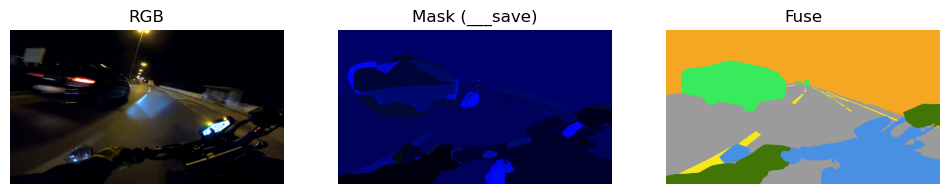

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 랜덤 한 장 확인
img_p, mask_p = pairs[0]
fuse_p = IMG_DIR / f"{img_p.name}___fuse.png"

img = Image.open(img_p).convert("RGB")
mask = Image.open(mask_p)

print("img:", img.size, img.mode)
print("mask:", mask.size, mask.mode)

m = np.array(mask)
print("mask array shape:", m.shape, "dtype:", m.dtype)

# 마스크가 1채널인지(RGB인지) 체크
if m.ndim == 2:
    uniq = np.unique(m)
    print("unique values (up to 30):", uniq[:30], "count:", len(uniq))
else:
    uniq = np.unique(m.reshape(-1, m.shape[-1]), axis=0)
    print("unique colors (up to 30):", uniq[:30], "count:", len(uniq))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("RGB"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask); plt.title("Mask (___save)"); plt.axis("off")
plt.subplot(1,3,3)
if fuse_p.exists():
    plt.imshow(Image.open(fuse_p).convert("RGB")); plt.title("Fuse"); plt.axis("off")
else:
    plt.text(0.1, 0.5, "Fuse not found"); plt.axis("off")
plt.show()


In [3]:
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image

NUM_CLASSES = 6
SIZE = (288, 512)  # (H,W)

def build_color_map(mask_paths, max_scan=50):
    color_set = set()
    for p in mask_paths[:max_scan]:
        m_pil = Image.open(p)
        # ✅ RGBA/P 등일 수 있으니 RGB로 통일
        if m_pil.mode != "RGB":
            m_pil = m_pil.convert("RGB")
        m = np.array(m_pil)

        # 혹시 1채널 인덱스면 None
        if m.ndim == 2:
            return None

        colors = np.unique(m.reshape(-1, 3), axis=0)
        for c in colors:
            color_set.add(tuple(c.tolist()))

    color_list = sorted(list(color_set))
    return {c: i for i, c in enumerate(color_list)}

def mask_to_index(mask_pil, color2idx=None):
    # ✅ 모드 통일
    if mask_pil.mode != "RGB" and color2idx is not None:
        mask_pil = mask_pil.convert("RGB")

    m = np.array(mask_pil)

    # 1채널 마스크(정수 인덱스)인 경우
    if m.ndim == 2:
        return torch.from_numpy(m).long()

    # RGB 컬러 마스크인 경우
    if color2idx is None:
        raise ValueError("RGB 마스크인데 color2idx가 None입니다.")

    h, w, _ = m.shape
    flat = m.reshape(-1, 3)
    out = np.zeros((flat.shape[0],), dtype=np.int64)

    for color, idx in color2idx.items():
        c = np.array(color, dtype=np.uint8)
        out[np.all(flat == c, axis=1)] = idx

    return torch.from_numpy(out.reshape(h, w)).long()

class NightRideDataset(Dataset):
    def __init__(self, pairs, color2idx=None, train=True):
        self.pairs = pairs
        self.color2idx = color2idx
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        img_p, mask_p = self.pairs[i]
        img = Image.open(img_p).convert("RGB")
        mask = Image.open(mask_p)

        # ✅ 마스크는 RGB로 통일(중요!)
        if mask.mode in ["RGBA", "LA", "P"]:
            mask = mask.convert("RGB")

        # resize
        img = TF.resize(img, SIZE, interpolation=Image.BILINEAR)
        mask = TF.resize(mask, SIZE, interpolation=Image.NEAREST)

        # augmentation
        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img); mask = TF.hflip(mask)
            if random.random() < 0.7:
                b = random.uniform(0.7, 1.3)
                c = random.uniform(0.7, 1.3)
                img = TF.adjust_brightness(img, b)
                img = TF.adjust_contrast(img, c)
            if random.random() < 0.5:
                g = random.uniform(0.7, 1.5)
                img = TF.adjust_gamma(img, g)

        # tensor + normalize
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

        mask = mask_to_index(mask, self.color2idx)
        mask = torch.clamp(mask, 0, NUM_CLASSES-1)
        return img, mask

# =========================
# Dataset split (시간순)
# =========================
n = len(pairs)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_pairs = pairs[:train_end]
val_pairs   = pairs[train_end:val_end]
test_pairs  = pairs[val_end:]

print("train / val / test:", len(train_pairs), len(val_pairs), len(test_pairs))

# =========================
# color map 생성 (train 기준)
# =========================
color2idx = build_color_map([m for _, m in train_pairs])
print("color2idx:", "1-channel mask" if color2idx is None else len(color2idx))

# =========================
# Dataset 객체 생성
# =========================
train_ds = NightRideDataset(train_pairs, color2idx=color2idx, train=True)
val_ds   = NightRideDataset(val_pairs,   color2idx=color2idx, train=False)
test_ds  = NightRideDataset(test_pairs,  color2idx=color2idx, train=False)

# =========================
# DataLoader 생성 (디버깅용 num_workers=0)
# =========================
train_loader = DataLoader(train_ds, batch_size=4, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

print("DataLoader ready ✔")



train / val / test: 140 30 30
color2idx: 323
DataLoader ready ✔


In [5]:
import torch
import torch.nn as nn
import torchvision
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# 모델: pretrained DeepLabV3 -> classifier 교체
model = torchvision.models.segmentation.deeplabv3_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

@torch.no_grad()
def compute_iou(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        p = (pred == cls)
        t = (target == cls)
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union == 0:
            ious.append(float("nan"))
        else:
            ious.append(inter/union)
    return np.array(ious, dtype=np.float32), float(np.nanmean(ious))

@torch.no_grad()
def evaluate(loader):
    model.eval()
    miou_list = []
    pc_sum = np.zeros(NUM_CLASSES, dtype=np.float64)
    pc_cnt = np.zeros(NUM_CLASSES, dtype=np.float64)

    for imgs, masks in loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        out = model(imgs)["out"]
        preds = out.argmax(dim=1)

        for b in range(preds.size(0)):
            ious, miou = compute_iou(preds[b], masks[b], NUM_CLASSES)
            miou_list.append(miou)
            for c in range(NUM_CLASSES):
                if not np.isnan(ious[c]):
                    pc_sum[c] += ious[c]
                    pc_cnt[c] += 1

    pc_iou = pc_sum / np.maximum(pc_cnt, 1)
    return float(np.mean(miou_list)), pc_iou

best_val = -1
best_path = "best_deeplabv3_nightride.pth"

EPOCHS = 1
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        out = model(imgs)["out"]
        loss = criterion(out, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    val_miou, val_pc = evaluate(val_loader)
    if val_miou > best_val:
        best_val = val_miou
        torch.save(model.state_dict(), best_path)

    print(f"[{epoch:02d}/{EPOCHS}] loss={total_loss/len(train_loader):.4f} | val mIoU={val_miou:.4f} | best={best_val:.4f}")

print("Saved best:", best_path)

# test 평가
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
test_miou, test_pc = evaluate(test_loader)

print("\n[Test] mIoU:", test_miou)
for name, iou in zip(CLASS_NAMES, test_pc):
    print(f" - {name:10s}: {iou:.4f}")


DEVICE: cuda
[01/5] loss=1.4160 | val mIoU=0.2440 | best=0.2440
[02/5] loss=0.9694 | val mIoU=0.2650 | best=0.2650
[03/5] loss=0.7826 | val mIoU=0.2575 | best=0.2650
[04/5] loss=0.6638 | val mIoU=0.2494 | best=0.2650
[05/5] loss=0.5810 | val mIoU=0.2338 | best=0.2650
Saved best: best_deeplabv3_nightride.pth

[Test] mIoU: 0.2733725461658378


NameError: name 'CLASS_NAMES' is not defined

In [ ]:
import os
import matplotlib.pyplot as plt

@torch.no_grad()
def denorm(img_t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    x = img_t.cpu()*std + mean
    return torch.clamp(x, 0, 1)

@torch.no_grad()
def save_failure_cases(k=10, threshold=0.40, out_dir="failure_cases"):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()

    saved = 0
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        out = model(imgs)["out"]
        preds = out.argmax(dim=1)

        for b in range(imgs.size(0)):
            _, miou = compute_iou(preds[b], masks[b], NUM_CLASSES)
            if miou < threshold:
                fig, ax = plt.subplots(1, 3, figsize=(12, 4))
                ax[0].imshow(denorm(imgs[b]).permute(1,2,0)); ax[0].set_title("RGB"); ax[0].axis("off")
                ax[1].imshow(masks[b].cpu(), vmin=0, vmax=NUM_CLASSES-1); ax[1].set_title("GT"); ax[1].axis("off")
                ax[2].imshow(preds[b].cpu(), vmin=0, vmax=NUM_CLASSES-1); ax[2].set_title(f"Pred (mIoU={miou:.2f})"); ax[2].axis("off")
                plt.tight_layout()
                plt.savefig(os.path.join(out_dir, f"fail_{saved:02d}.png"), dpi=150)
                plt.close(fig)

                saved += 1
                if saved >= k:
                    print(f"Saved {saved} failure cases to ./{out_dir}/")
                    return
    print(f"Saved {saved} failure cases to ./{out_dir}/ (not enough low-mIoU samples)")

save_failure_cases(k=10, threshold=0.40)
